<a href="https://colab.research.google.com/github/QuAdrUp0/Data-Mining-Actual/blob/main/Datasetnew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Explore and prep data

In [ ]:
import pandas as pd
df = pd.read_csv('/content/F1-Races-2020-2024.csv', delimiter=',')

In [ ]:
df.head()

,year,round,circuitId,date,rainy,Turns,Length,driverId,constructorId,grid,...,laps,statusId,Weighted_Top_3_Probability,Weighted_Top_3_Prob_Length,position_previous_race,nro_cond_escuderia,raceId,prom_points_10,Top 3 Finish,points
0,2000,1,1,3/12/2000,0,14,5.278,2,20,15,...,56,12,0.087719,0.090909,8,2,158,9.4,0,0.0
1,2000,1,1,3/12/2000,0,14,5.278,14,1,2,...,11,5,0.208333,0.222222,20,2,158,47.6,0,0.0
2,2000,1,1,3/12/2000,0,14,5.278,15,17,6,...,35,5,0.048387,0.083333,20,2,158,8.5,0,0.0
3,2000,1,1,3/12/2000,0,14,5.278,18,3,21,...,46,5,0.160494,0.235294,20,2,158,1.2,0,0.0
4,2000,1,1,3/12/2000,0,14,5.278,21,22,9,...,58,1,0.076923,0.100000,11,1,158,4.5,0,2.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9839 entries, 0 to 9838
Data columns (total 34 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   year                                                            9839 non-null   int64  
 1   round                                                           9839 non-null   int64  
 2   circuitId                                                       9839 non-null   int64  
 3   date                                                            9839 non-null   object 
 4   rainy                                                           9839 non-null   int64  
 5   Turns                                                           9839 non-null   int64  
 6   Length                                                          9839 non-null   float64
 7   driverId                                           

In [ ]:
# Drop columns that are less related to the target based on my judgement
# cols_to_drop = ['circuitId', 'driverId', 'round']
# cols_to_drop = ['points_driver_champ', 'wins', 'points_cons_champ', 'wins_cons']
cols_to_drop = ['year', 'raceId']
df = df.drop(columns=cols_to_drop)

In [ ]:
# Rename columns so they are understandable
df = df.rename(columns={'Driver Top 3 Finish Percentage (Last Year)' : 'd_top3_plastyear',
                   'Constructor Top 3 Finish Percentage (Last Year)' : 'c_top3_plastyear',
                   'Driver Top 3 Finish Percentage (This Year till last race)' : 'd_top3_pthisyear',
                   'Constructor Top 3 Finish Percentage (This Year till last race)' : 'c_top3_pthisyear',
                   'Driver Avg position (Last Year)' : 'driver_avg_pos',
                   'Constructor Average Position (This Year till last race)' : 'cons_avg_pos_thisyear',
                   'Weighted_Top_3_Probability' : 'wd_top3_p',
                   'Weighted_Top_3_Prob_Length' : 'wd_top3_pl',
                   'Constructor Avg position (Last Year)' : 'cons_avg_pos_lastyear',
                   'Driver Average Position (This Year till last race)' : 'd_avg_pos_thisyear'})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9839 entries, 0 to 9838
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   constructorId           9839 non-null   int64  
 1   grid                    9839 non-null   int64  
 2   d_top3_plastyear        9839 non-null   float64
 3   c_top3_plastyear        9839 non-null   float64
 4   d_top3_pthisyear        9839 non-null   float64
 5   c_top3_pthisyear        9839 non-null   float64
 6   driver_avg_pos          9839 non-null   float64
 7   cons_avg_pos_lastyear   9839 non-null   float64
 8   d_avg_pos_thisyear      9839 non-null   float64
 9   cons_avg_pos_thisyear   9839 non-null   float64
 10  driver_age              9839 non-null   int64  
 11  wd_top3_p               9839 non-null   float64
 12  wd_top3_pl              9839 non-null   float64
 13  position_previous_race  9839 non-null   int64  
 14  prom_points_10          9839 non-null   

# Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold

X = df.drop(columns=['points'])
y = df['points']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

# Initialize XGBoost Regressor


In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    tree_method='hist',
    device='cuda',
    enable_categorical=True,
    objective='reg:squarederror',
    random_state=42
)

Hyperparameter Grid

In [ ]:
param_grid = {
    'n_estimators': [100, 300, 500, 800],        # Number of trees
    'max_depth': [3, 5, 7, 9],                   # Depth of each tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2],     # Step size shrinkage
    'subsample': [0.7, 0.8, 0.9, 1.0],           # % of samples used per tree (prevents overfitting)
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],    # % of features used per tree
    'min_child_weight': [1, 3, 5]                # Minimum sum of instance weight needed in a child
}

RandomizedSearch CV

In [ ]:
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,                  # Number of parameter settings sampled
    scoring='neg_mean_absolute_error', # Optimizing to minimize MAE
    cv=5,                       # 5-fold cross-validation
    verbose=1,                  # Print progress
    n_jobs=-1,                  # Use all available CPU cores
    random_state=42
)

In [ ]:
# 9. Execute Hyperparameter Tuning
print("Starting hyperparameter tuning... This might take a few minutes.")
search.fit(X_train, y_train)

Starting hyperparameter tuning... This might take a few minutes.
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device='cuda',
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constrain...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 300, 500, 800],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [ ]:
# 10. Extract the Best Model
best_xgb = search.best_estimator_
print(f"\nBest Hyperparameters Found: {search.best_params_}")

# 11. Make Predictions on the Test Set
y_pred = best_xgb.predict(X_test)


Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# 12. Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} points")
print(f"R-squared (R2): {r2:.4f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): 5.46 points
R-squared (R2): 0.9655


In [ ]:
# Feature Importance
# Show which variables the model relied on the most
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importances.head(10))


Top 10 Most Important Features:
                   Feature  Importance
16          prom_points_10    0.431225
5         d_top3_pthisyear    0.309583
6         c_top3_pthisyear    0.044358
3         d_top3_plastyear    0.034828
9       d_avg_pos_thisyear    0.030303
0                     year    0.023638
14  position_previous_race    0.019228
4         c_top3_plastyear    0.018283
10   cons_avg_pos_thisyear    0.016815
15                  raceId    0.016682


/tmp/ipykernel_4192/2221160378.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


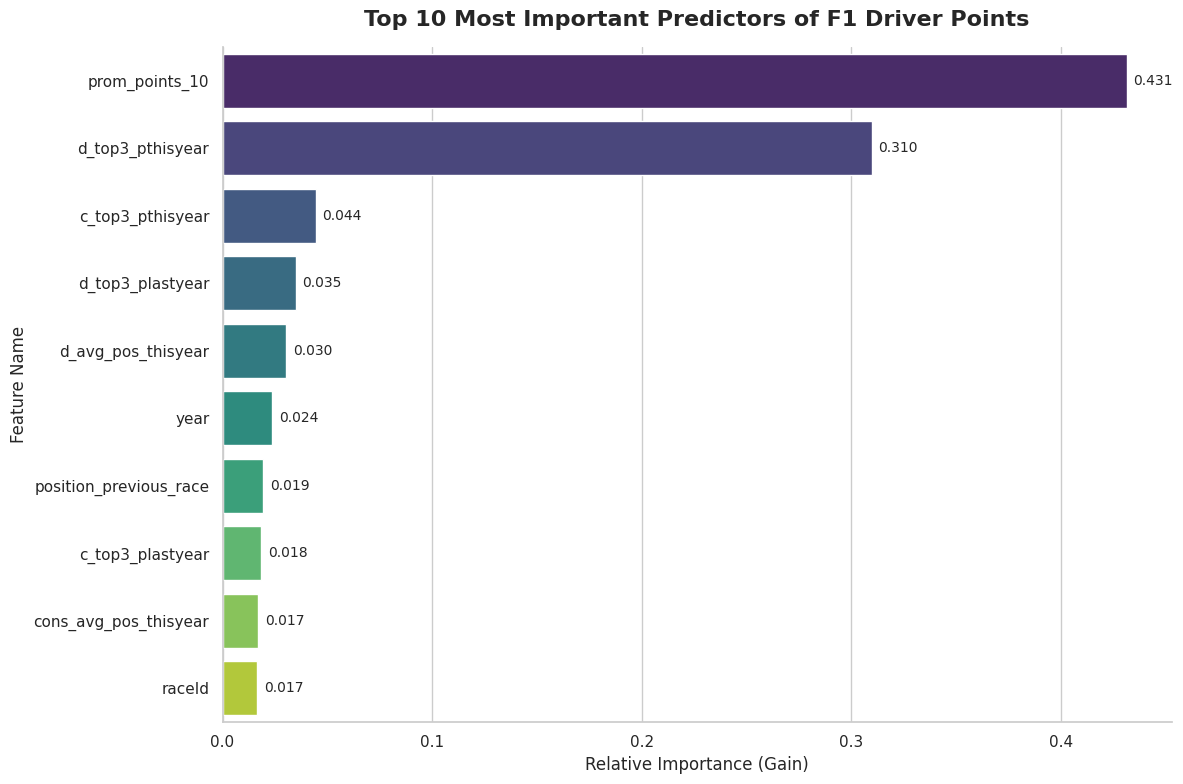

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the feature importances from the model
importances = best_xgb.feature_importances_
feature_names = X_test.columns

# 2. Put them into a DataFrame and sort them
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 3. Select only the Top 15
top_15_features = importance_df.head(10)

# 4. Set up the visual style
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 5. Create the horizontal bar chart
ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=top_15_features,
    palette='viridis' # A nice color gradient
)

# 6. Add labels and titles
plt.title('Top 10 Most Important Predictors of F1 Driver Points', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# Optional: Add the actual numbers to the end of the bars for readability
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=10)

# Remove the top and right borders for a cleaner look
sns.despine()
plt.tight_layout()
plt.show()